<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/MobileNetV3-Refined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV3Large # or MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
SAVE_PATH = '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/mobilenetv3_finetuned.keras'

In [ ]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
NUM_CLASSES = 14

In [ ]:
print("Setting up Generators with MobileNetV3 Preprocessing...")

# CRITICAL: MobileNetV3 expects pixels [0-255], NOT [0-1].
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    vertical_flip=True,          # Good for top-down forage shots
    brightness_range=[0.9, 1.1], # Robustness to lighting
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

Setting up Generators with MobileNetV3 Preprocessing...


In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3577 images belonging to 14 classes.
Found 763 images belonging to 14 classes.


In [ ]:
print("\nComputing Class Weights...")
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print(f"Weights: {class_weights_dict}")


Computing Class Weights...
Weights: {0: np.float64(0.998046875), 1: np.float64(1.0780590717299579), 2: np.float64(0.9324817518248175), 3: np.float64(1.0179282868525896), 4: np.float64(0.9569288389513109), 5: np.float64(0.9462962962962963), 6: np.float64(1.0735294117647058), 7: np.float64(1.0557851239669422), 8: np.float64(1.0179282868525896), 9: np.float64(0.9533582089552238), 10: np.float64(0.9428044280442804), 11: np.float64(1.0872340425531914), 12: np.float64(1.0179282868525896), 13: np.float64(0.9605263157894737)}


In [ ]:
# Building the model
print("\nBuilding Model...")

base_model = MobileNetV3Large(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False # Freeze the base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(), # Stabilizes training
    layers.Dropout(0.2), # Slight increase for better generalization
    layers.Dense(256, activation='swish', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.1),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)


Building Model...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [ ]:
# Feature Extraction
print("\n--- STAGE 1: Training Head ---")

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_stage1 = model.fit(
    train_generator,
    epochs=20, # Short run just to train the head
    validation_data=val_generator,
    class_weight=class_weights_dict, # Apply weights
    callbacks=[early_stopping],
)


--- STAGE 1: Training Head ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 120s 887ms/step - accuracy: 0.1914 - loss: 2.7156 - val_accuracy: 0.5269 - val_loss: 1.6526
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 581ms/step - accuracy: 0.5672 - loss: 1.5216 - val_accuracy: 0.6999 - val_loss: 1.2194
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 578ms/step - accuracy: 0.6968 - loss: 1.1908 - val_accuracy: 0.7706 - val_loss: 1.0366
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 582ms/step - accuracy: 0.7346 - loss: 1.0783 - val_accuracy: 0.7929 - val_loss: 0.9565
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 581ms/step - accuracy: 0.7635 - loss: 0.9974 - val_accuracy: 0.8165 - val_loss: 0.9027
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 580ms/step - accuracy: 0.7776 - loss: 0.9576 - val_accuracy: 0.8336 - val_loss: 0.8687
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 578ms/step - accuracy: 0.8098 - loss: 0.9017 - val_accuracy: 0.8545 - val_loss: 0.8404
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 583ms/step - accuracy: 0.8360 - loss: 

In [50]:
print("\n--- STAGE 2: Fine-Tuning (Backbone Unfrozen) ---")

# Unfreeze the base model
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

fine_tune_at = 80

for layer in base_model.layers[:fine_tune_at]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with LOW Learning Rate (10x smaller)
model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# New callbacks for the long run
early_stopping_ft = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath=SAVE_PATH, save_best_only=True, monitor='val_loss')
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)

history_fine = model.fit(
    train_generator,
    epochs=100, # Long run
    initial_epoch=history_stage1.epoch[-1], # Resume where Stage 1 left off
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_ft, model_checkpoint],
)


--- STAGE 2: Fine-Tuning (Backbone Unfrozen) ---
Epoch 20/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 98s 756ms/step - accuracy: 0.9042 - loss: 0.6701 - val_accuracy: 0.9030 - val_loss: 0.6814
Epoch 21/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 66s 592ms/step - accuracy: 0.9151 - loss: 0.6561 - val_accuracy: 0.9004 - val_loss: 0.6795
Epoch 22/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 66s 587ms/step - accuracy: 0.9141 - loss: 0.6523 - val_accuracy: 0.9017 - val_loss: 0.6794
Epoch 23/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 66s 585ms/step - accuracy: 0.9104 - loss: 0.6496 - val_accuracy: 0.9043 - val_loss: 0.6751
Epoch 24/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 65s 584ms/step - accuracy: 0.9179 - loss: 0.6414 - val_accuracy: 0.9043 - val_loss: 0.6730
Epoch 25/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 66s 588ms/step - accuracy: 0.9131 - loss: 0.6442 - val_accuracy: 0.9030 - val_loss: 0.6699
Epoch 26/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 66s 585ms/step - accuracy: 0.9217 - loss: 0.6385 - val_accuracy: 0.9056 - val_loss: 0.6689
Epoch 27/100
112/11

In [51]:
def plot_full_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    plt.figure(figsize=(12, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Acc')
    plt.plot(val_acc, label='Validation Acc')
    # Draw line where fine-tuning started
    plt.plot([len(h1.history['accuracy'])-1, len(h1.history['accuracy'])-1],
             plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('MobileNetV3 - Training and Validation Accuracy')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.plot([len(h1.history['loss'])-1, len(h1.history['loss'])-1],
             plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('MobileNetV3 -Training and Validation Loss')
    plt.show()


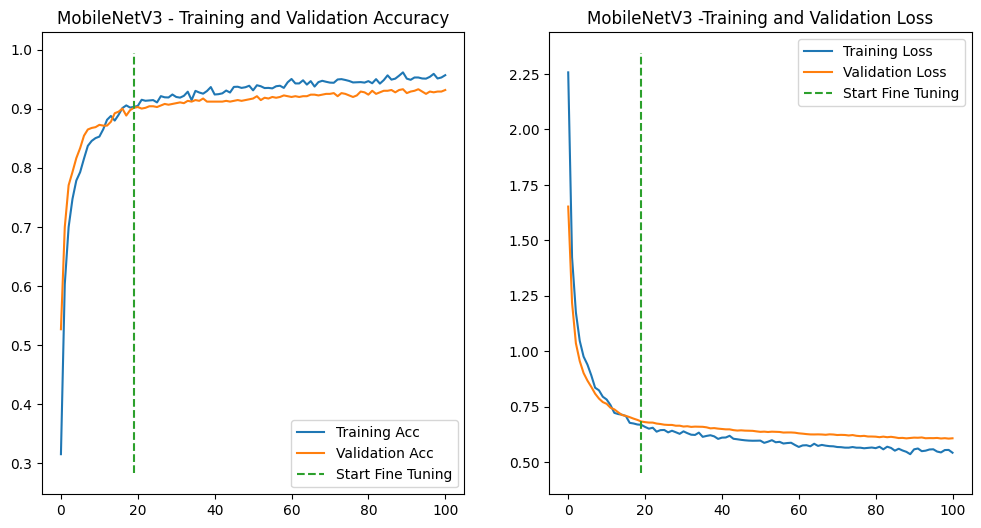

In [52]:
plot_full_history(history_stage1, history_fine)